# Working with Regression Trees in Python

## Learning Objectives
Decision Trees are one of the most popular approaches to supervised machine learning. Decison Trees use an inverted tree-like structure to model the relationship between independent variables and a dependent variable. A tree with a continuous dependent variable is known as a **Regression Tree**. By the end of this tutorial, you will have learned:

+ How to import, explore and prepare data
+ How to build a Regression Tree model
+ How to visualize the structure of a Regression Tree
+ How to Prune a Regression Tree 

## 1. Collect the Data

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree

df = pd.read_csv('train_ke.csv')

# Feature engineering — same per-capita logic as your OLS
df['gdp_per_capita'] = df['GDP_EUR_billion'] * 1000 / df['population_million']  # EUR thousands, or keep billions/million

# Bucket store counts into tiers
def store_tier(s):
    if s <= 7:
        return 'xsmall (5-7)'
    elif s <= 12:
        return 'small (8-12)'
    elif s <= 19:
        return 'mid (13-19)'
    else:
        return 'large (20+)'

df['store_tier'] = df['total_active_stores'].apply(store_tier)

X = df[['gdp_per_capita', 'population_million']]
y = df['store_tier']

# Heavily constrained — you only have 21 rows
tree = DecisionTreeClassifier(max_depth=1, min_samples_leaf=5, random_state=42)
tree.fit(X, y)

# Predict for your 4 target markets
targets = pd.DataFrame({
    'country': ['Norway', 'Czech Republic', 'Poland', 'Portugal'],
    'gdp_per_capita': [105454, 30556, 23370, 25962],
    'population_million': [5.5, 10.8, 36.8, 10.4]
})
targets['predicted_tier'] = tree.predict(targets[['gdp_per_capita', 'population_million']])
print(targets)

          country  gdp_per_capita  population_million predicted_tier
0          Norway          105454                 5.5   xsmall (5-7)
1  Czech Republic           30556                10.8   xsmall (5-7)
2          Poland           23370                36.8   xsmall (5-7)
3        Portugal           25962                10.4   xsmall (5-7)


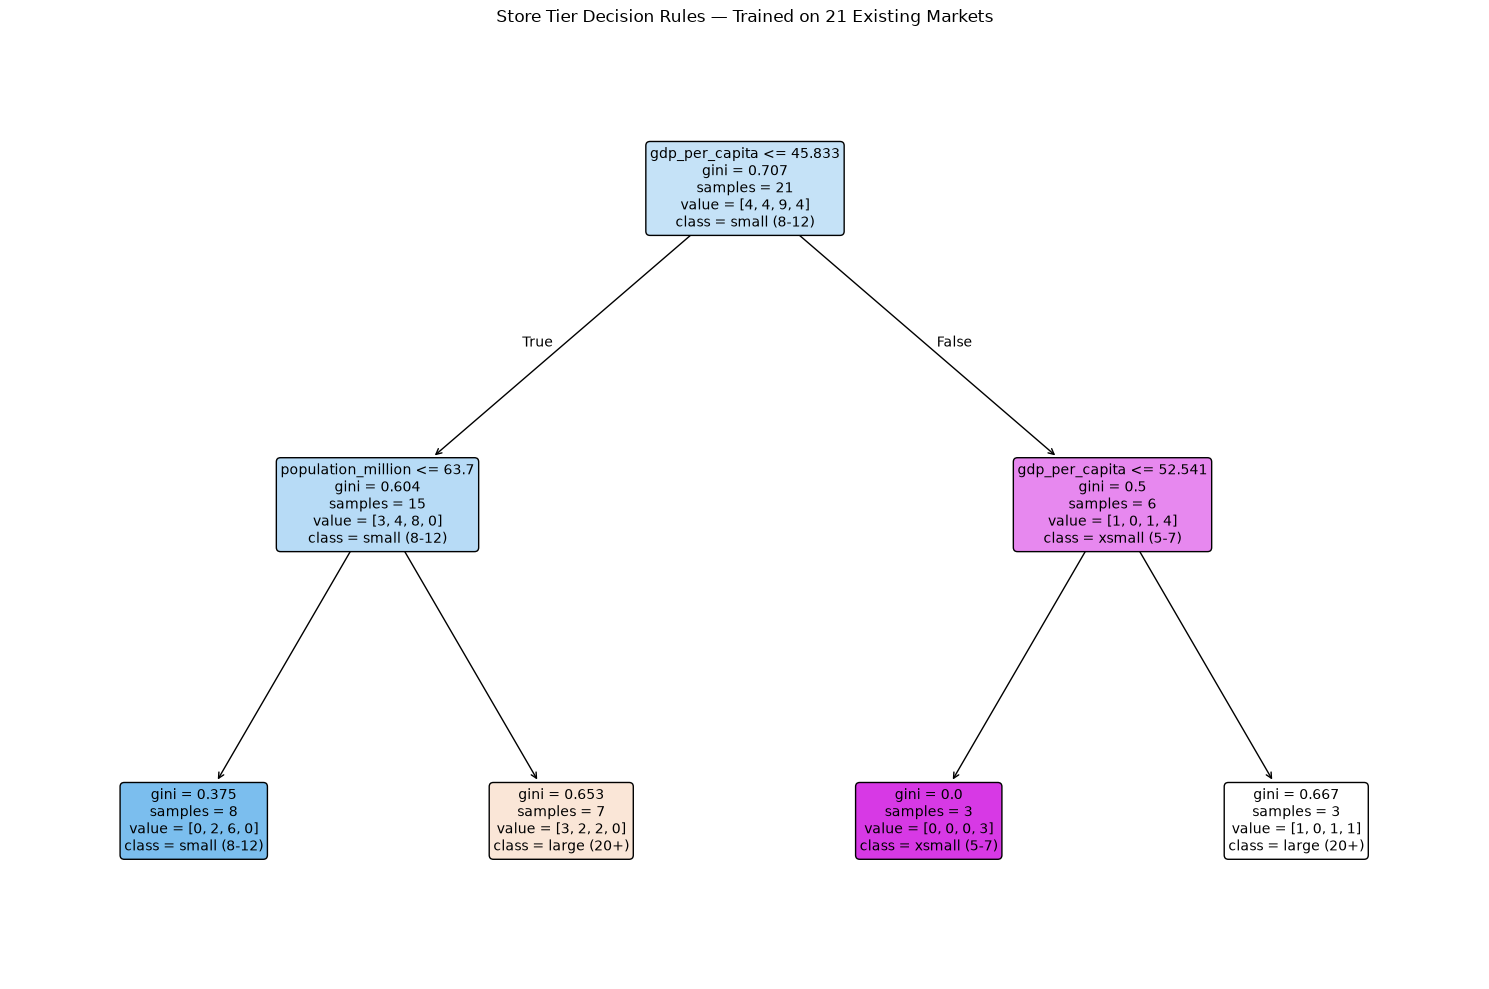

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Fit on the 21 KNOWN countries — features X, true labels y (store_tier)
classifier = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=3,
    random_state=1234
)
model = classifier.fit(X, y)   # y = df['store_tier'], not targets['predicted_tier']

# THEN predict on the 4 new markets separately
targets['predicted_tier'] = model.predict(targets[['gdp_per_capita', 'population_million']])

# Plot the tree that was trained on the 21 known countries
plt.figure(figsize=(15, 10))
tree.plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Store Tier Decision Rules — Trained on 21 Existing Markets")
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()




[0.71711712 0.28288288]


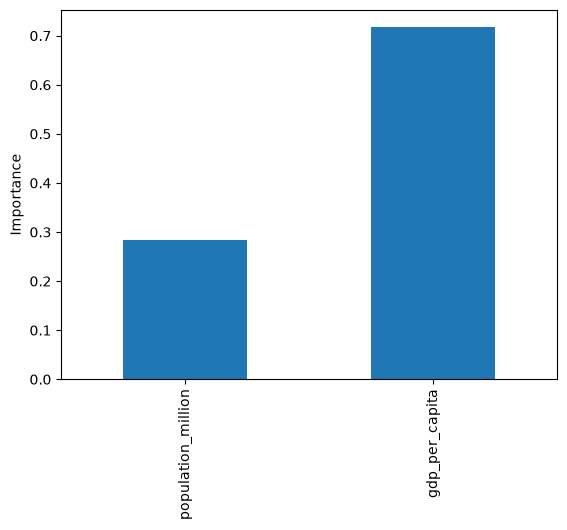

In [4]:
importance = model.feature_importances_
print(importance)
feature_importance = pd.Series(importance, index = X.columns)
feature_importance.sort_values().plot(kind = 'bar')
plt.ylabel('Importance');

In [5]:
import pandas as pd
income = pd.read_csv("train_ke.csv")
income.head()

,country,total_active_stores,total_revenue,GDP_EUR_billion,population_million
0,United States,54,3684763,17.561,327.0
1,United Kingdom,21,1494919,2.406,67.0
2,Korea,8,1182129,1.377,51.6
3,Germany,15,1623699,3.443,83.4
4,Switzerland,6,1343717,0.604,8.5


## 2. Explore the Data

In [6]:
income.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              21 non-null     str    
 1   total_active_stores  21 non-null     int64  
 2   total_revenue        21 non-null     int64  
 3   GDP_EUR_billion      21 non-null     float64
 4   population_million   21 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 1.1 KB


In [7]:
income.describe()

,total_active_stores,total_revenue,GDP_EUR_billion,population_million
count,21.000000,2.100000e+01,21.000000,21.000000
mean,13.761905,9.309804e+05,2.619952,128.614286
std,10.539947,7.638468e+05,4.244522,301.878554
min,5.000000,2.253070e+05,0.213000,5.520000
25%,8.000000,4.286170e+05,0.476000,10.200000
50%,10.000000,6.976680e+05,1.216000,46.700000
75%,17.000000,1.182454e+06,2.363000,83.400000
max,54.000000,3.684763e+06,17.561000,1400.000000


In [8]:
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

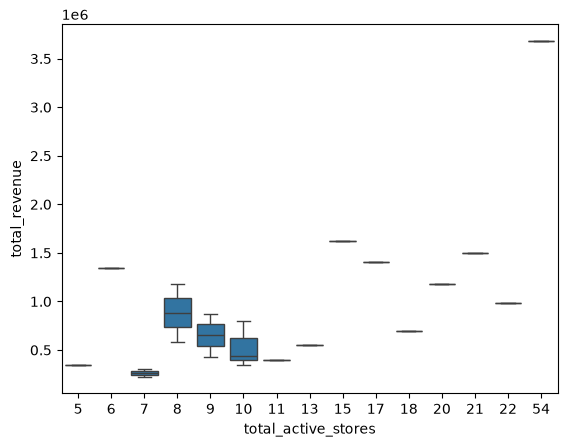

In [9]:
ax = sns.boxplot(data = income, x = 'total_active_stores', y = 'total_revenue')

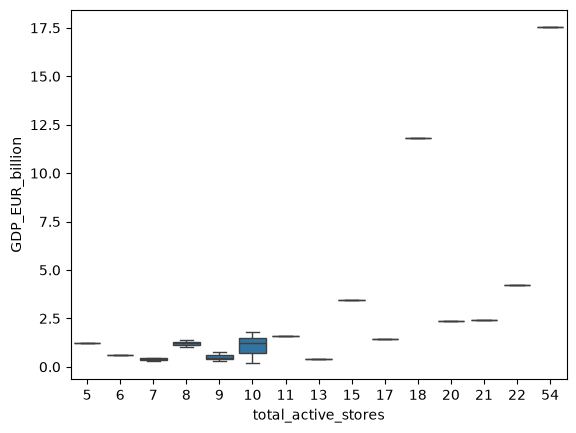

In [10]:
ax = sns.boxplot(data = income, x = 'total_active_stores', y = 'GDP_EUR_billion')

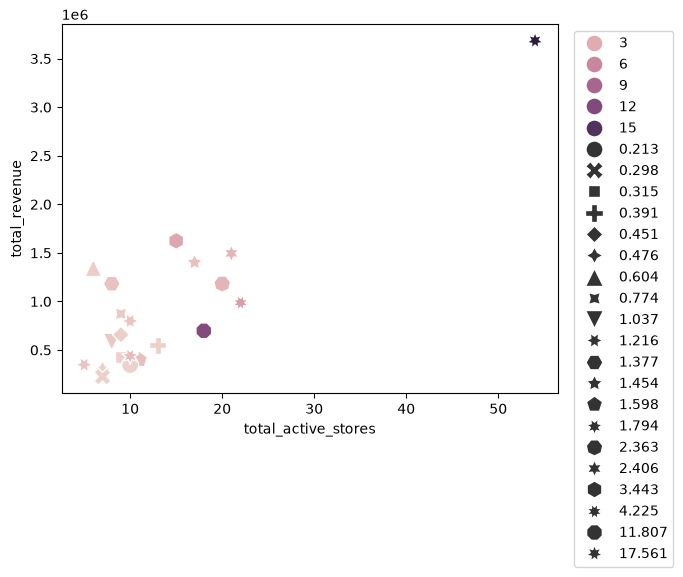

In [11]:
ax = sns.scatterplot(data = income, 
                     x = 'total_active_stores', 
                     y = 'total_revenue', 
                     hue = 'GDP_EUR_billion', 
                     style = 'GDP_EUR_billion', 
                     s = 150)
ax = plt.legend(bbox_to_anchor = (1.02, 1), loc = 'upper left')

## 3. Prepare the Data

In [12]:
y = income[['total_revenue']]

In [13]:
X = income[['total_active_stores', 'GDP_EUR_billion']]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.8,
                                                    random_state = 1) 

In [15]:
X_train.shape, X_test.shape

((16, 2), (5, 2))

In [16]:
X_train.head()

,total_active_stores,GDP_EUR_billion
14,9,0.451
16,5,1.216
4,6,0.604
2,8,1.377
6,22,4.225


In [17]:
X_train = pd.get_dummies(X_train)
X_train.head()

,total_active_stores,GDP_EUR_billion
14,9,0.451
16,5,1.216
4,6,0.604
2,8,1.377
6,22,4.225


In [18]:
X_test = pd.get_dummies(X_test)
X_test.head()

,total_active_stores,GDP_EUR_billion
15,10,0.213
10,10,1.216
3,15,3.443
18,10,1.794
17,13,0.391


## 4. Train and Evaluate the Regression Tree

In [19]:
from sklearn.tree import DecisionTreeRegressor


In [20]:
model = regressor.fit(X_train, y_train)

NameError: name 'regressor' is not defined

In [ ]:
model.score(X_test, y_test)

0.03856333633615927

In [ ]:
y_test_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_test_pred)

308016.8

## 5. Visualize the Regression Tree

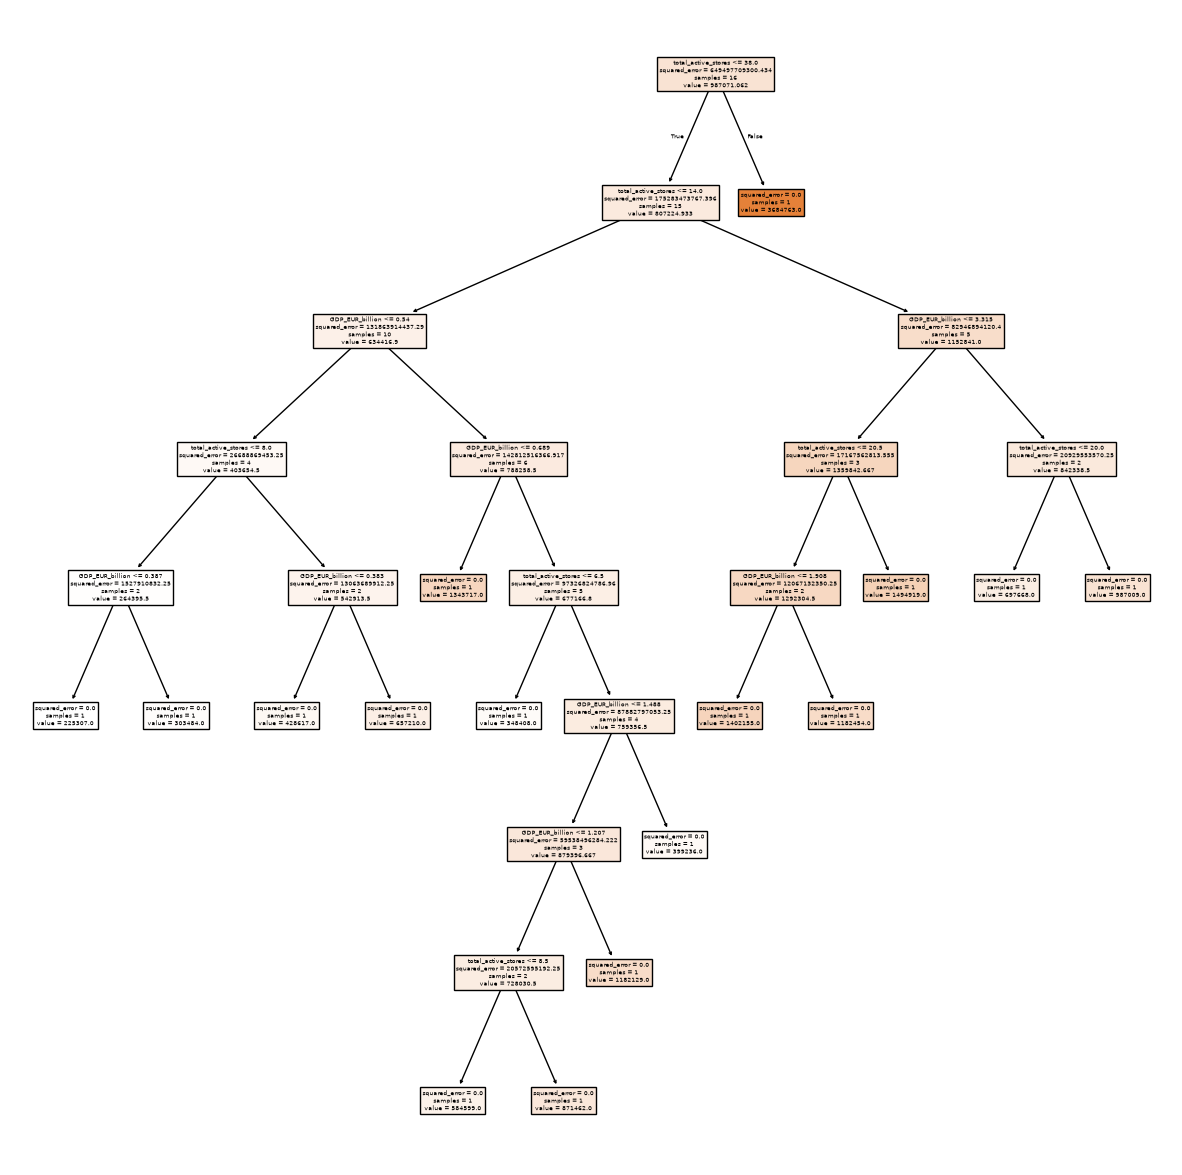

In [ ]:
from sklearn import tree
plt.figure(figsize = (15,15))
tree.plot_tree(model, 
                   feature_names = list(X_train.columns), 
                   filled = True);

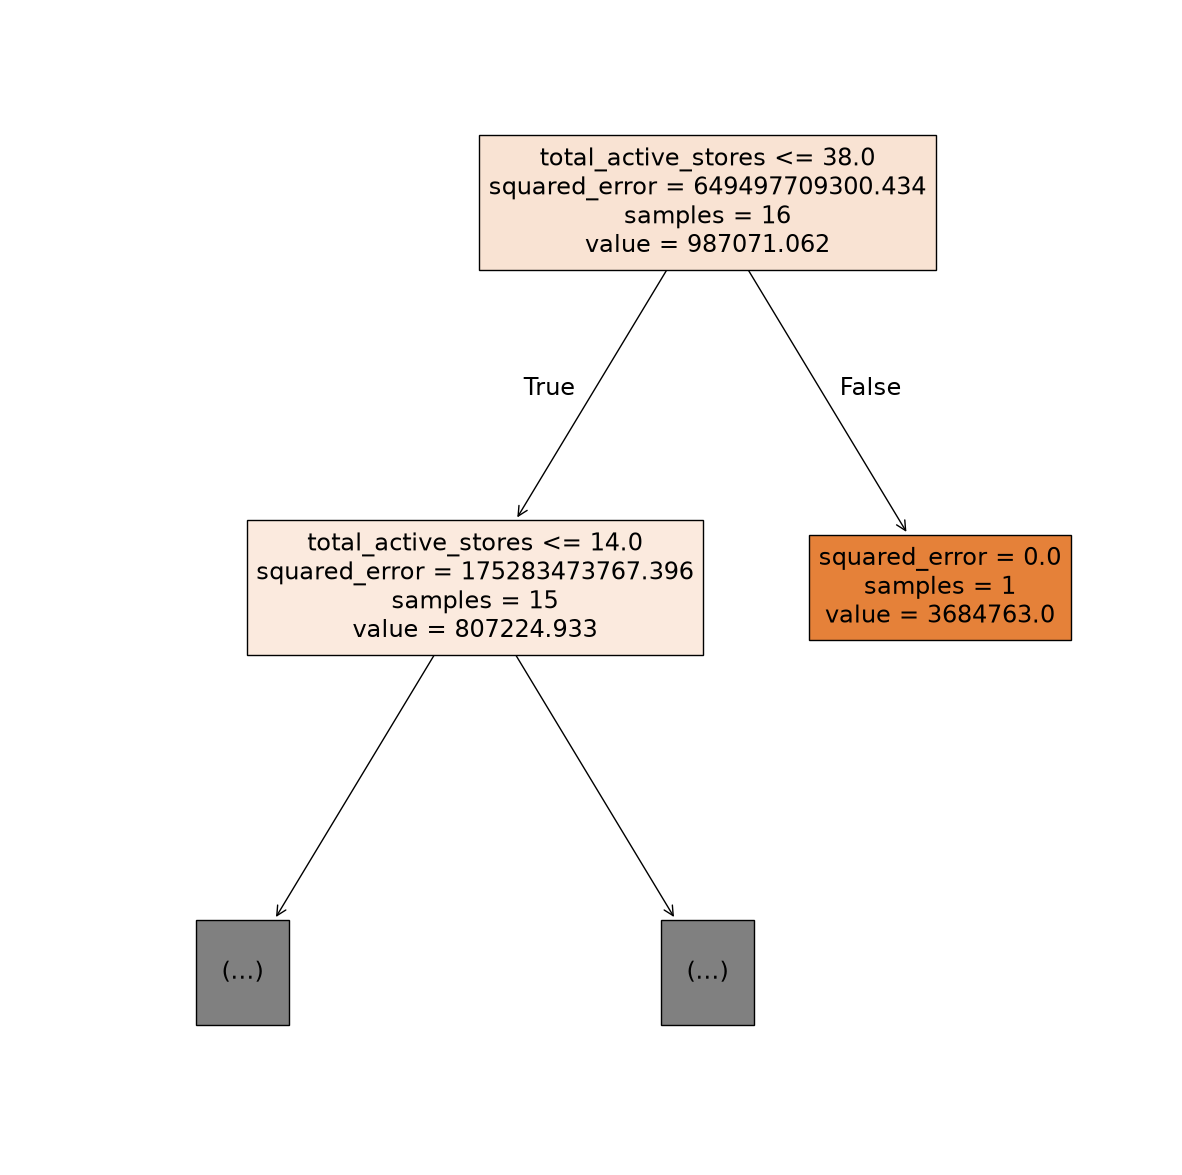

In [ ]:
plt.figure(figsize = (15,15))
tree.plot_tree(model, 
               feature_names = list(X_train.columns), 
               filled = True,
               max_depth = 1);

In [ ]:
importance = model.feature_importances_
importance

array([0.86428689, 0.13571311])

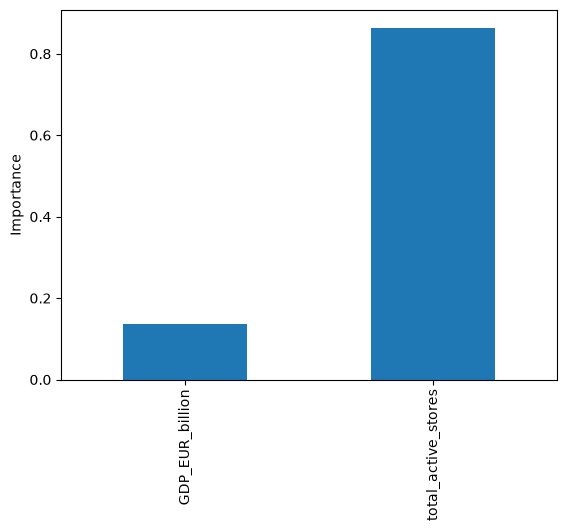

In [ ]:
feature_importance = pd.Series(importance, index = X_train.columns)
feature_importance.sort_values().plot(kind = 'bar')
plt.ylabel('Importance');

## 6. Prune the Regression Tree

In [ ]:
model.score(X_train, y_train)

1.0

In [ ]:
model.score(X_test, y_test)

0.03856333633615927

Let's get the list of effective alphas for the training data.

In [ ]:
path = regressor.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
list(ccp_alphas)

[np.float64(0.0),
 np.float64(190988854.03125),
 np.float64(1508391543.78125),
 np.float64(1632961239.03125),
 np.float64(1710526483.7603912),
 np.float64(2571574399.03125),
 np.float64(2616194196.28125),
 np.float64(4848267270.25),
 np.float64(8591893654.26043),
 np.float64(9625582346.316645),
 np.float64(20085792188.80208),
 np.float64(22664048207.034386),
 np.float64(55992405721.002075),
 np.float64(485169452643.5003)]

We remove the maximum effective alpha because it is the trivial tree with just one node.

In [ ]:
ccp_alphas = ccp_alphas[:-1]
list(ccp_alphas)

[np.float64(0.0),
 np.float64(190988854.03125),
 np.float64(1508391543.78125),
 np.float64(1632961239.03125),
 np.float64(1710526483.7603912),
 np.float64(2571574399.03125),
 np.float64(2616194196.28125),
 np.float64(4848267270.25),
 np.float64(8591893654.26043),
 np.float64(9625582346.316645),
 np.float64(20085792188.80208),
 np.float64(22664048207.034386),
 np.float64(55992405721.002075)]

Next, we train several trees using the different values for alpha.

In [ ]:
train_scores, test_scores = [], []
for alpha in ccp_alphas:
    regressor_ = DecisionTreeRegressor(random_state = 1234, ccp_alpha = alpha)
    model_ = regressor_.fit(X_train, y_train)
    train_scores.append(model_.score(X_train, y_train))
    test_scores.append(model_.score(X_test, y_test))

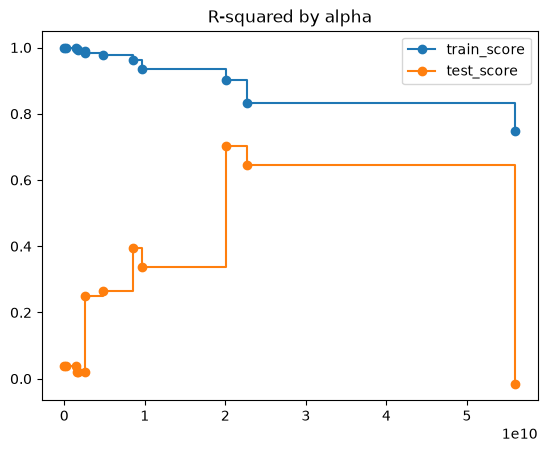

In [ ]:
plt.plot(ccp_alphas, 
         train_scores, 
         marker = "o", 
         label = 'train_score', 
         drawstyle = "steps-post")
plt.plot(ccp_alphas, 
         test_scores, 
         marker = "o", 
         label = 'test_score', 
         drawstyle = "steps-post")
plt.legend()
plt.title('R-squared by alpha');

In [ ]:
test_scores

[0.03856333633615927,
 0.03856333633615927,
 0.03856333633615927,
 0.01878891149752271,
 0.01878891149752271,
 0.01878891149752271,
 0.2505369377811655,
 0.2637796115900821,
 0.3958203398995471,
 0.3367642359673232,
 0.7015586365833061,
 0.6459063351800942,
 -0.014572084777419558]

In [ ]:
ix = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[ix]
best_alpha

np.float64(20085792188.80208)

In [ ]:
regressor_ = DecisionTreeRegressor(random_state = 1234, ccp_alpha = best_alpha)
model_ = regressor_.fit(X_train, y_train)

In [ ]:
model_.score(X_train, y_train)

0.9029900281099876

In [ ]:
model_.score(X_test, y_test)

0.7015586365833061

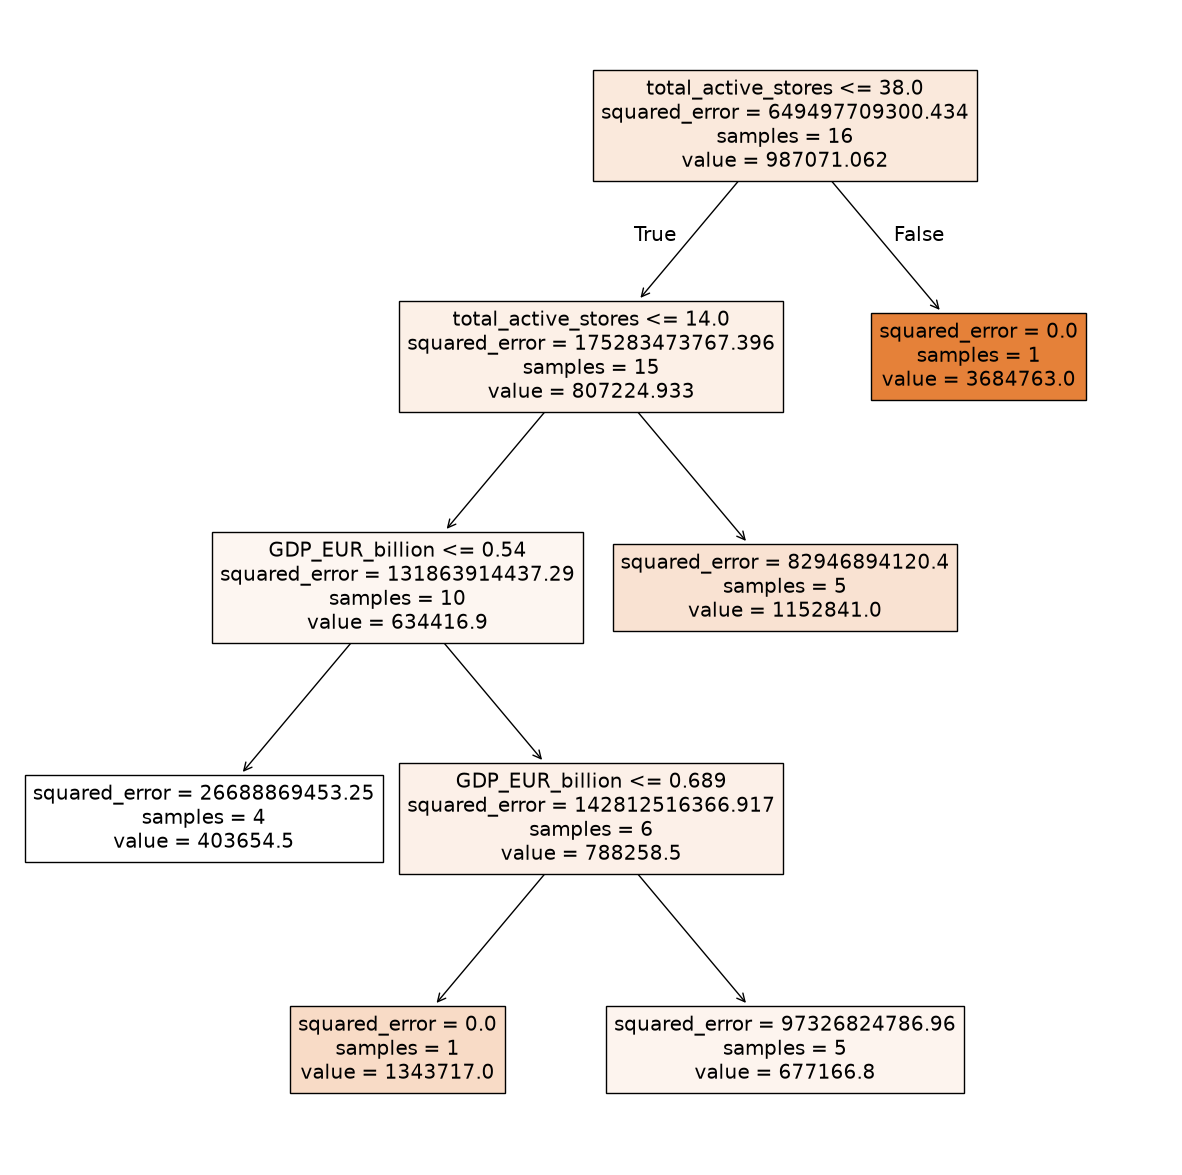

In [ ]:
plt.figure(figsize = (15,15))
tree.plot_tree(model_, 
                   feature_names = list(X_train.columns),
                   filled = True);